# Simulate the spread of resistant bacteria in an evolution experiment

In [189]:
import numpy as np
import matplotlib.pyplot as plt

## Parameters

In [190]:
number_generations = 412 #value from Bons et al

e_coli_replicate_time = 26 #minutes
initial_number_bacteria = 1.84e7 #number per well - value from Bons et al

initial_phage_density = 3.6e5 #number/microlitre - value from Bons et al
volume_phage = 4 #microlitres - value from Bons et al

passaging_time = 26 #minutes #try 180 minutes
volume_transferred = 4 #microlitres - value from Bons et al
volume_of_well = 200 #microlitres - value from Bons et al
burst_size = 50 #fits our simulations to keep MOI<~1

initial_number_resistant = 0.92e7
mutation_rate = 10e-7 #prob bacteria becoming resistant when replicating

wellplate_cycle ="no"   #Increases number of bakteria with inreasing wellnumber on the same plate


## Simulation

In [191]:
#Simulations
end_number_phages = np.zeros(number_generations)
end_number_bacteria = np.zeros(number_generations)
end_number_resistant = np.zeros(number_generations)

end_number_bacteria[0] = initial_number_bacteria - initial_number_resistant
end_number_resistant[0] = initial_number_resistant
end_number_phages[0] = initial_phage_density*volume_phage

for generation in range(1,number_generations):

  if wellplate_cycle =="yes":
    # well number inreases aslong as the same 96 well plate is used(for 12 generations)
    well_number_bacteria = initial_number_bacteria*2**(((generation-1)%12)*passaging_time/e_coli_replicate_time)

    #Transfer from previous well into a fresh well
    number_phages = (volume_transferred/volume_of_well)*end_number_phages[generation-1]
    number_bacteria = well_number_bacteria + (volume_transferred/volume_of_well)*end_number_bacteria[generation-1]\
      -well_number_bacteria*mutation_rate
    number_resistant = (volume_transferred/volume_of_well)*end_number_resistant[generation-1]\
      + well_number_bacteria*mutation_rate

  else:
     #Transfer from previous well into a fresh well
    number_phages = (volume_transferred/volume_of_well)*end_number_phages[generation-1]
    number_bacteria = initial_number_bacteria + (volume_transferred/volume_of_well)*end_number_bacteria[generation-1]\
      - initial_number_bacteria*mutation_rate
    number_resistant = (volume_transferred/volume_of_well)*end_number_resistant[generation-1]\
      + initial_number_bacteria*mutation_rate


        # number_resistant = initial_number_resistant + (volume_transferred/volume_of_well)*end_number_resistant[generation-1]

    #Each replication cycle (i.e. one cycle)
  for _ in range(int(np.floor(passaging_time/e_coli_replicate_time))):
      #Must have an integer
      number_bacteria = np.floor(number_bacteria)
      number_resistant = np.floor(number_resistant)
      number_phages = np.floor(number_phages)

      #Some bacteria are infected - assumes well mixed, all phages adsorb to a bacteria at random
      number_infected = number_bacteria*(1-((1-1/(number_bacteria+number_resistant))**number_phages))

      #Infected bacteria burst
      number_phages = number_phages + burst_size*number_infected

      #Infected bacteria die
      number_bacteria -= number_infected

      #Remaining bacteria, and all resistant bacteria replicate
      number_bacteria = number_bacteria*2
      number_resistant = number_resistant*2

      #Some bacteria mutate to become resistant
      number_mutants = np.floor(number_bacteria*mutation_rate) #for small mutation rates
      number_bacteria -= number_mutants
      number_resistant += number_mutants

    #Save values
      end_number_phages[generation] = number_phages
      end_number_bacteria[generation] = number_bacteria
      end_number_resistant[generation] = number_resistant


[9.20000e+06 3.68073e+05 1.47960e+04 6.66000e+02 1.00000e+02 7.80000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01 7.60000e+01
, 7.60000e+01 7.60000e+01 7.60000e+01 7

## Results

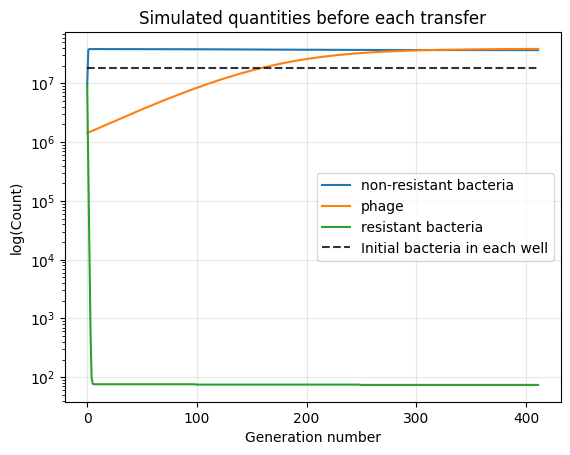

In [192]:
#Plot results
plt.plot(end_number_bacteria, label='non-resistant bacteria')
plt.plot(end_number_phages, label='phage')
plt.plot(end_number_resistant, label='resistant bacteria')
plt.plot(np.arange(number_generations), np.zeros(number_generations) + initial_number_bacteria, '--', color='black', alpha=0.8, label='Initial bacteria in each well')
plt.grid(alpha=0.3)
plt.yscale('log')
plt.xlabel('Generation number')
plt.ylabel('log(Count)')
plt.legend()
plt.title('Simulated quantities before each transfer')
plt.show()